<a href="https://colab.research.google.com/github/parviza9999/Credit-Card-Fraud-Detection-/blob/main/notebooks/01_complete_eda_credit_card_fraud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [7]:
import pandas as pd

file_path = "/content/drive/MyDrive/Interview Node/Capstone_Project/Fraud Detection GCP Capstone/data/raw/creditcard.csv"

df = pd.read_csv(file_path)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


In [ ]:
df.shape

(284807, 31)

In [8]:
df["Class"].value_counts()

,count
Class,
0,284315
1,492


In [9]:
df["Class"].value_counts(normalize=True) * 100

,proportion
Class,
0,99.8273
1,0.1727


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [11]:
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": (df.isnull().sum() / len(df)) * 100
})

missing_summary.sort_values("missing_count", ascending=False)

,missing_count,missing_percent
Time,0,0.0000
V1,0,0.0000
V2,0,0.0000
V3,0,0.0000
V4,0,0.0000
V5,0,0.0000
V6,0,0.0000
V7,0,0.0000
V8,0,0.0000
V9,0,0.0000


In [12]:
duplicate_count = df.duplicated().sum()
duplicate_percent = duplicate_count / len(df) * 100

print("Duplicate rows:", duplicate_count)
print("Duplicate percentage:", duplicate_percent)

Duplicate rows: 1081
Duplicate percentage: 0.379555277784605


In [13]:
class_counts = df["Class"].value_counts().rename(index={0: "Non-Fraud", 1: "Fraud"})
class_percentages = df["Class"].value_counts(normalize=True).rename(index={0: "Non-Fraud", 1: "Fraud"}) * 100

class_distribution = pd.DataFrame({
    "count": class_counts,
    "percent": class_percentages
})

class_distribution

,count,percent
Class,,
Non-Fraud,284315,99.8273
Fraud,492,0.1727


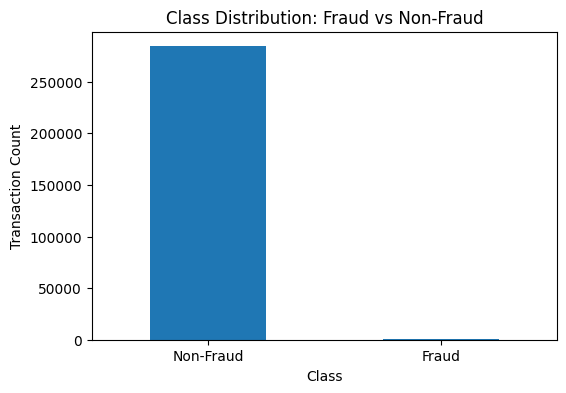

In [14]:
plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar")
plt.title("Class Distribution: Fraud vs Non-Fraud")
plt.xlabel("Class")
plt.ylabel("Transaction Count")
plt.xticks(rotation=0)
plt.show()

In [15]:
fraud_count = df[df["Class"] == 1].shape[0]
non_fraud_count = df[df["Class"] == 0].shape[0]
fraud_percent = fraud_count / len(df) * 100

print(f"Fraud transactions: {fraud_count}")
print(f"Non-fraud transactions: {non_fraud_count}")
print(f"Fraud percentage: {fraud_percent:.4f}%")

Fraud transactions: 492
Non-fraud transactions: 284315
Fraud percentage: 0.1727%


In [16]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,"284,807.0000","94,813.8596","47,488.1460",0.0000,"54,201.5000","84,692.0000","139,320.5000","172,792.0000"
V1,"284,807.0000",0.0000,1.9587,-56.4075,-0.9204,0.0181,1.3156,2.4549
V2,"284,807.0000",0.0000,1.6513,-72.7157,-0.5985,0.0655,0.8037,22.0577
V3,"284,807.0000",-0.0000,1.5163,-48.3256,-0.8904,0.1798,1.0272,9.3826
V4,"284,807.0000",0.0000,1.4159,-5.6832,-0.8486,-0.0198,0.7433,16.8753
V5,"284,807.0000",0.0000,1.3802,-113.7433,-0.6916,-0.0543,0.6119,34.8017
V6,"284,807.0000",0.0000,1.3323,-26.1605,-0.7683,-0.2742,0.3986,73.3016
V7,"284,807.0000",-0.0000,1.2371,-43.5572,-0.5541,0.0401,0.5704,120.5895
V8,"284,807.0000",0.0000,1.1944,-73.2167,-0.2086,0.0224,0.3273,20.0072
V9,"284,807.0000",-0.0000,1.0986,-13.4341,-0.6431,-0.0514,0.5971,15.5950


In [17]:
amount_by_class = df.groupby("Class")["Amount"].describe()
amount_by_class

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,"284,315.0000",88.2910,250.1051,0.0000,5.6500,22.0000,77.0500,"25,691.1600"
1,492.0000,122.2113,256.6833,0.0000,1.0000,9.2500,105.8900,"2,125.8700"


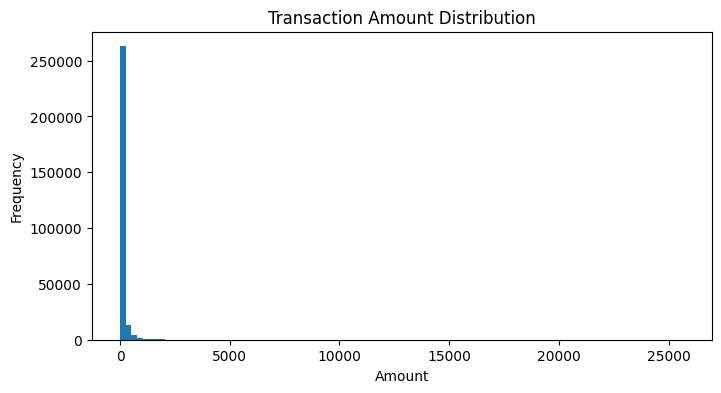

In [18]:
plt.figure(figsize=(8, 4))
df["Amount"].plot(kind="hist", bins=100)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

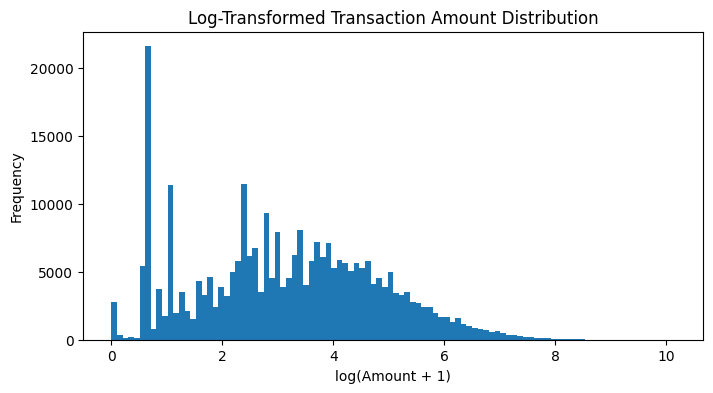

In [19]:
df["Log_Amount"] = np.log1p(df["Amount"])

plt.figure(figsize=(8, 4))
df["Log_Amount"].plot(kind="hist", bins=100)
plt.title("Log-Transformed Transaction Amount Distribution")
plt.xlabel("log(Amount + 1)")
plt.ylabel("Frequency")
plt.show()

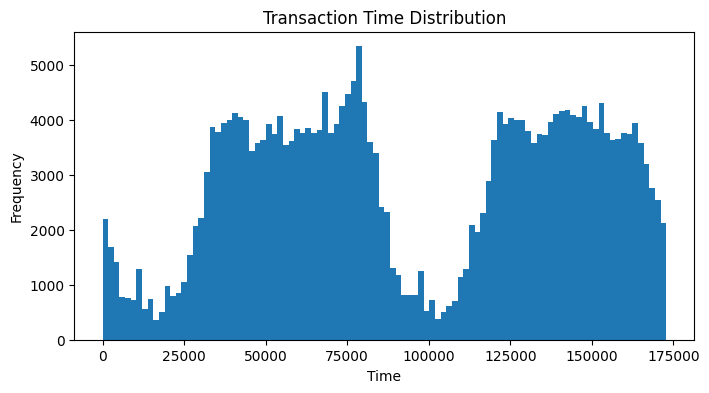

In [20]:
plt.figure(figsize=(8, 4))
df["Time"].plot(kind="hist", bins=100)
plt.title("Transaction Time Distribution")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.show()

In [21]:
corr_matrix = df.drop(columns=["Log_Amount"]).corr()

corr_matrix

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
Time,1.0000,0.1174,-0.0106,-0.4196,-0.1053,0.1731,-0.0630,0.0847,-0.0369,-0.0087,0.0306,-0.2477,0.1243,-0.0659,-0.0988,-0.1835,0.0119,-0.0733,0.0904,0.0290,-0.0509,0.0447,0.1441,0.0511,-0.0162,-0.2331,-0.0414,-0.0051,-0.0094,-0.0106,-0.0123
V1,0.1174,1.0000,0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,-0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,-0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,-0.0000,0.0000,0.0000,-0.2277,-0.1013
V2,-0.0106,0.0000,1.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000,-0.0000,-0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000,-0.0000,-0.5314,0.0913
V3,-0.4196,-0.0000,0.0000,1.0000,0.0000,-0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,0.0000,0.0000,-0.2109,-0.1930
V4,-0.1053,-0.0000,-0.0000,0.0000,1.0000,-0.0000,-0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,-0.0000,-0.0000,-0.0000,-0.0000,-0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0987,0.1334
V5,0.1731,0.0000,0.0000,-0.0000,-0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,-0.3864,-0.0950
V6,-0.0630,-0.0000,0.0000,0.0000,-0.0000,0.0000,1.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,-0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000,-0.0000,-0.0000,0.0000,0.2160,-0.0436
V7,0.0847,-0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,-0.0000,-0.0000,0.3973,-0.1873
V8,-0.0369,-0.0000,-0.0000,-0.0000,0.0000,0.0000,-0.0000,0.0000,1.0000,0.0000,-0.0000,0.0000,0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,-0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.1031,0.0199
V9,-0.0087,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,-0.0000,0.0000,-0.0000,0.0000,0.0000,-0.0000,-0.0000,0.0000,0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,0.0000,-0.0442,-0.0977


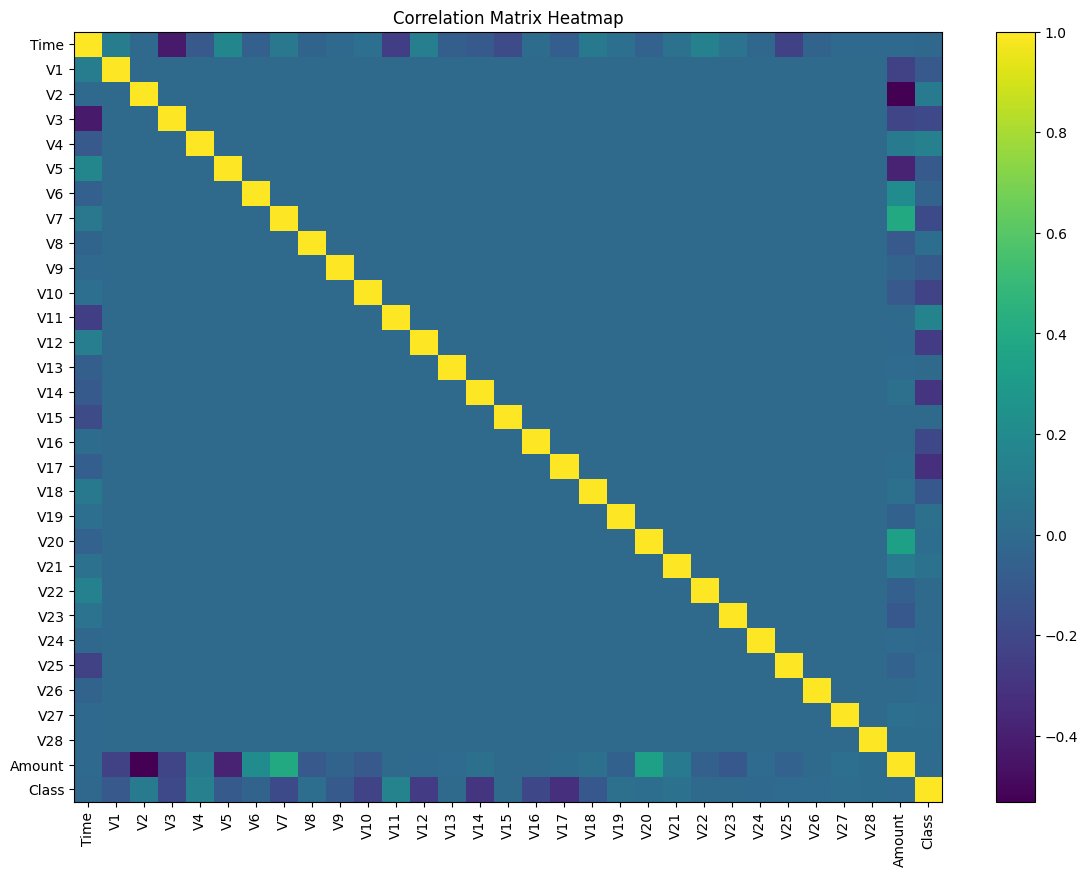

In [22]:
plt.figure(figsize=(14, 10))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Matrix Heatmap")
plt.show()

In [23]:
target_corr = corr_matrix["Class"].drop("Class").sort_values(key=abs, ascending=False)

target_corr

,Class
V17,-0.3265
V14,-0.3025
V12,-0.2606
V10,-0.2169
V16,-0.1965
V3,-0.1930
V7,-0.1873
V11,0.1549
V4,0.1334
V18,-0.1115


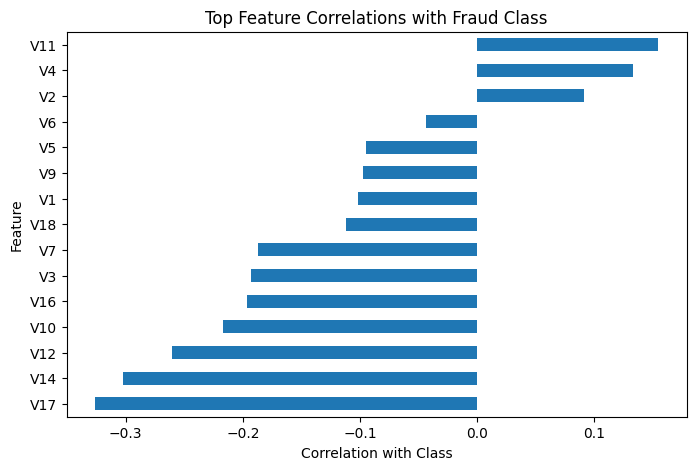

In [24]:
top_target_corr = target_corr.head(15)

plt.figure(figsize=(8, 5))
top_target_corr.sort_values().plot(kind="barh")
plt.title("Top Feature Correlations with Fraud Class")
plt.xlabel("Correlation with Class")
plt.ylabel("Feature")
plt.show()

In [25]:
features_only = df.drop(columns=["Class", "Log_Amount"])

feature_corr = features_only.corr().abs()

upper_triangle = feature_corr.where(
    np.triu(np.ones(feature_corr.shape), k=1).astype(bool)
)

high_corr_pairs = (
    upper_triangle.stack()
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "abs_correlation"})
    .sort_values("abs_correlation", ascending=False)
)

high_corr_pairs.head(20)

,feature_1,feature_2,abs_correlation
83,V2,Amount,0.5314
2,Time,V3,0.4196
203,V7,Amount,0.3973
158,V5,Amount,0.3864
398,V20,Amount,0.3394
10,Time,V11,0.2477
24,Time,V25,0.2331
56,V1,Amount,0.2277
181,V6,Amount,0.2160
109,V3,Amount,0.2109


In [26]:
strong_corr_pairs = high_corr_pairs[high_corr_pairs["abs_correlation"] >= 0.80]

strong_corr_pairs

,feature_1,feature_2,abs_correlation


## Multicollinearity Discussion

The multicollinearity review identifies whether any independent variables are strongly correlated with each other. Strong feature-to-feature correlation can affect linear models and feature interpretation. Because most variables in this dataset are PCA-transformed components, high multicollinearity is not expected among V1–V28. However, this check is included to document feature relationships before modeling.

VIF analysis

Variance Inflation Factor can be computationally heavier, but this dataset is manageable. Use a sample first if needed.

In [28]:
vif_features = df.drop(columns=["Class", "Log_Amount"]).copy()

# Scale before VIF calculation
scaler = StandardScaler()
vif_scaled = scaler.fit_transform(vif_features)

vif_df = pd.DataFrame()
vif_df["feature"] = vif_features.columns
vif_df["VIF"] = [
    variance_inflation_factor(vif_scaled, i)
    for i in range(vif_scaled.shape[1])
]

vif_df.sort_values("VIF", ascending=False)

,feature,VIF
29,Amount,12.1167
2,V2,4.4224
7,V7,2.9290
5,V5,2.8593
20,V20,2.3992
0,Time,1.8799
3,V3,1.8773
1,V1,1.6519
6,V6,1.5715
23,V23,1.1581


## VIF Interpretation

Variance Inflation Factor was used to check whether any feature can be strongly explained by other features. A high VIF may indicate multicollinearity. Since V1–V28 are PCA-transformed variables, high VIF values are not expected for those features. If Time or Amount show elevated VIF, those features should be reviewed during model development.

In [29]:
amount_q1 = df["Amount"].quantile(0.25)
amount_q3 = df["Amount"].quantile(0.75)
amount_iqr = amount_q3 - amount_q1

lower_bound = amount_q1 - 1.5 * amount_iqr
upper_bound = amount_q3 + 1.5 * amount_iqr

amount_outliers = df[(df["Amount"] < lower_bound) | (df["Amount"] > upper_bound)]

print("Amount Q1:", amount_q1)
print("Amount Q3:", amount_q3)
print("Amount IQR:", amount_iqr)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Amount outlier count:", amount_outliers.shape[0])
print("Amount outlier percentage:", amount_outliers.shape[0] / len(df) * 100)

Amount Q1: 5.6
Amount Q3: 77.16499999999999
Amount IQR: 71.565
Lower bound: -101.7475
Upper bound: 184.5125
Amount outlier count: 31904
Amount outlier percentage: 11.201971861646658


In [30]:
amount_outlier_fraud_rate = amount_outliers["Class"].mean() * 100

print(f"Fraud rate among amount outliers: {amount_outlier_fraud_rate:.4f}%")

Fraud rate among amount outliers: 0.2852%


In [31]:
eda_summary = {
    "total_rows": df.shape[0],
    "total_columns": df.shape[1],
    "fraud_count": fraud_count,
    "non_fraud_count": non_fraud_count,
    "fraud_percent": fraud_percent,
    "total_missing_values": int(df.isnull().sum().sum()),
    "duplicate_rows": int(duplicate_count),
    "amount_outlier_count": int(amount_outliers.shape[0])
}

eda_summary_df = pd.DataFrame([eda_summary])
eda_summary_df

,total_rows,total_columns,fraud_count,non_fraud_count,fraud_percent,total_missing_values,duplicate_rows,amount_outlier_count
0,284807,32,492,284315,0.1727,0,1081,31904


In [34]:
output_folder = "/content/drive/MyDrive/Interview Node/Capstone_Project/Fraud Detection GCP Capstone/reports"

eda_summary_df.to_csv(f"{output_folder}/eda_summary.csv", index=False)
target_corr.to_csv(f"{output_folder}/target_correlations.csv")
high_corr_pairs.to_csv(f"{output_folder}/feature_correlation_pairs.csv", index=False)
vif_df.to_csv(f"{output_folder}/vif_results.csv", index=False)

print("EDA report files saved.")

EDA report files saved.


# EDA Findings Summary

The dataset contains credit card transactions with a highly imbalanced target variable. Fraud cases represent a very small fraction of the total dataset, which means accuracy alone is not an appropriate performance metric.

The EDA reviewed dataset structure, missing values, duplicate records, transaction amount distribution, time distribution, class imbalance, feature correlations, feature-to-feature collinearity, and Variance Inflation Factor.

Key modeling implications:

1. The model must be evaluated using precision, recall, F1-score, ROC-AUC, PR-AUC, and confusion matrix analysis.
2. Stratified train/test splitting is required to preserve the fraud ratio.
3. Scaling should be fitted only on the training data to avoid data leakage.
4. Class imbalance must be handled using appropriate methods such as class weighting, anomaly detection, threshold tuning, or resampling.
5. Correlation and VIF results should be documented, but PCA-transformed features V1–V28 are expected to have limited multicollinearity.
6. Outlier behavior in transaction amount should be reviewed but not automatically removed because extreme values may contain important fraud signals.